# Experiment - EfficientNet-B0 transfer learning (discarded)

A systematic comparison on whole slides: a small CNN trained from scratch, then EfficientNet-B0 as a frozen feature extractor, then the same network fine-tuned. Includes the exploratory data analysis of class balance and image sizes.

Discarded with the rest of the whole-slide family once tiles proved better.

---


## **Google Drive Connection**

In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain train_data/, test_data/ and train_labels.csv
# (see data/README.md).
import os

DATA_DIR = os.environ.get("WSI_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## **Libraries Import**

In [2]:
# Set seed for reproducibility
SEED = 54

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torchview import draw_graph

logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


## **Data Loading**

In [3]:
# Paths to data folders and labels file in Drive
TRAIN_IMG_DIR = 'Dataset/train_img_data'
TRAIN_MASK_DIR = 'Dataset/train_mask_data'
TEST_DATA_DIR = 'Dataset/test_data'
TRAIN_LABELS_PATH = 'Dataset/train_labels.csv'

# Verify paths exist
print("="*70)
print("CHECKING DATA PATHS")
print("="*70)

if os.path.exists(TRAIN_IMG_DIR):
    train_img_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.png')]
    print(f"Train images folder found")
    print(f"Path: {TRAIN_IMG_DIR}")
    print(f"Total files: {len(train_img_files)}")
else:
    print(f"Train images folder NOT found at: {TRAIN_IMG_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TRAIN_MASK_DIR):
    train_mask_files = [f for f in os.listdir(TRAIN_MASK_DIR) if f.endswith('.png')]
    print(f"\n Train masks folder found")
    print(f"Path: {TRAIN_MASK_DIR}")
    print(f"Total files: {len(train_mask_files)}")
else:
    print(f"\n Train masks folder NOT found at: {TRAIN_MASK_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TEST_DATA_DIR):
    test_files = [f for f in os.listdir(TEST_DATA_DIR) if f.endswith('.png')]
    print(f"\n Test data folder found")
    print(f"Path: {TEST_DATA_DIR}")
    print(f"Total files: {len(test_files)}")
else:
    print(f"\n Test data folder NOT found at: {TEST_DATA_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TRAIN_LABELS_PATH):
    print(f"\n Labels file found")
    print(f"Path: {TRAIN_LABELS_PATH}")
else:
    print(f"\n Labels file NOT found at: {TRAIN_LABELS_PATH}")
    print(f"Please check your Google Drive path!")

print("\n" + "="*70)
print("PATH VERIFICATION COMPLETED")
print("="*70)

CHECKING DATA PATHS
 Train images folder found
  Path: Dataset/train_img_data
  Total files: 580

 Train masks folder found
  Path: Dataset/train_mask_data
  Total files: 580

 Test data folder found
  Path: Dataset/test_data
  Total files: 954

 Labels file found
  Path: Dataset/train_labels.csv

PATH VERIFICATION COMPLETED


## **Exploration and Data Analysis**

Train dataset size: 580

First rows of the dataset:
   sample_index            label
0  img_0000.png  Triple negative
1  img_0002.png        Luminal B
2  img_0003.png        Luminal B
3  img_0004.png        Luminal B
4  img_0006.png        Luminal A

CLASS DISTRIBUTION
label
Luminal B          204
Luminal A          157
HER2(+)            150
Triple negative     69
Name: count, dtype: int64


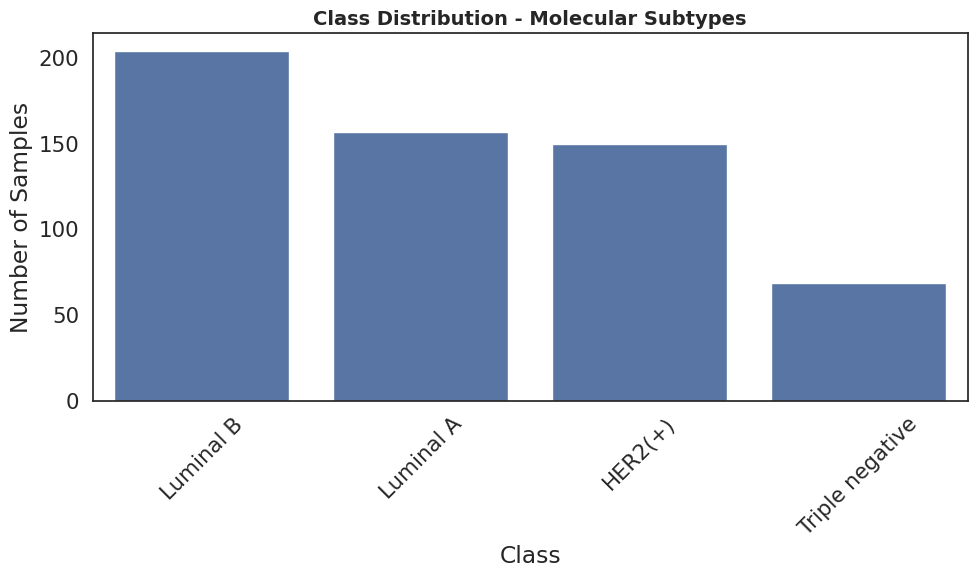


Number of classes: 4


In [4]:
# Load labels
train_labels = pd.read_csv(TRAIN_LABELS_PATH)
print(f"Train dataset size: {len(train_labels)}")
print("\nFirst rows of the dataset:")
print(train_labels.head())

# Class distribution analysis
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
class_counts = train_labels['label'].value_counts()
print(class_counts)

# Visualize distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution - Molecular Subtypes', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Class to index mapping
label_to_idx = {
    'Luminal A': 0,
    'Luminal B': 1,
    'HER2(+)': 2,
    'Triple negative': 3
}
idx_to_label = {v: k for k, v in label_to_idx.items()}

print(f"\nNumber of classes: {len(label_to_idx)}")


Visualizing sample images and masks...


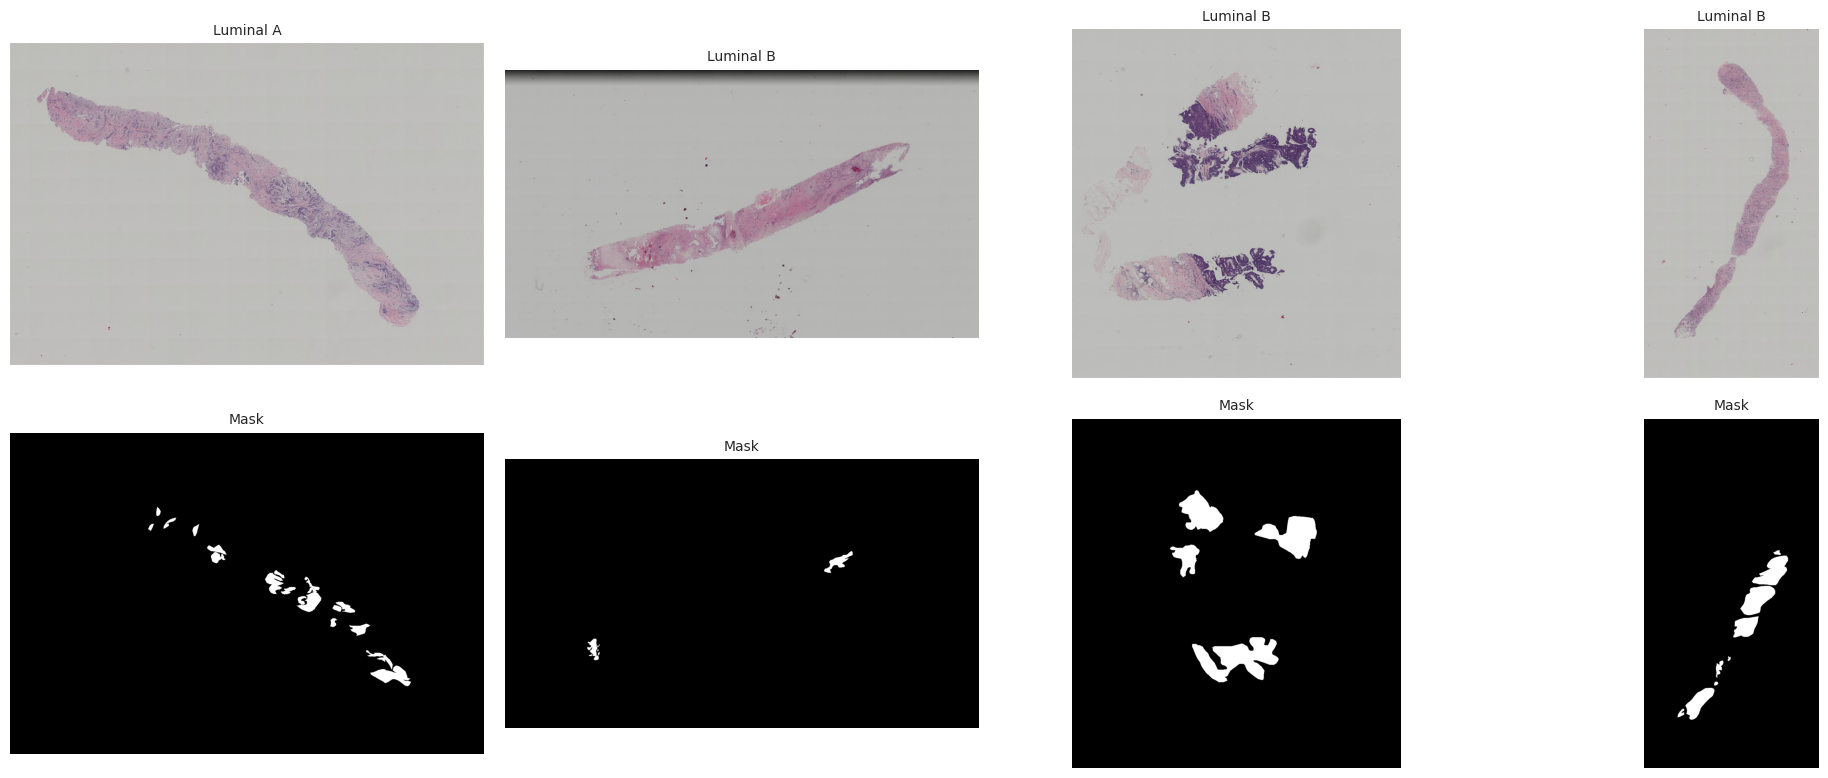

In [5]:
def visualize_samples(df, img_dir, mask_dir, n_samples=8, use_mask=True):
    """Visualize random samples with their masks"""
    if use_mask:
        fig, axes = plt.subplots(2, n_samples, figsize=(20, 8))
    else:
        fig, axes = plt.subplots(1, n_samples, figsize=(20, 4))
        axes = np.array([axes])  # Make it 2D for consistent indexing

    samples = df.sample(min(n_samples, len(df)))

    for idx, (_, row) in enumerate(samples.iterrows()):
        img_name = row['sample_index']
        label = row['label']

        # Load image
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)

        # Check if image was loaded successfully
        if img is None:
            print(f"Warning: Could not load image at {img_path}. Skipping.")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image
        axes[0, idx].imshow(img)
        axes[0, idx].set_title(f"{label}", fontsize=10)
        axes[0, idx].axis('off')

        # Load and display mask
        if use_mask:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = os.path.join(mask_dir, mask_name)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    axes[1, idx].imshow(mask, cmap='gray')
                    axes[1, idx].set_title(f"Mask", fontsize=10)
                    axes[1, idx].axis('off')
                else:
                    print(f"Warning: Could not load mask at {mask_path}")
                    axes[1, idx].axis('off')
            else:
                print(f"Warning: Mask not found at {mask_path}")
                axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizing sample images and masks...")
visualize_samples(train_labels, TRAIN_IMG_DIR, TRAIN_MASK_DIR, n_samples=4)

## **Data Preprocessing**

In [6]:
# class TissueDataset(Dataset):
#     """Custom Dataset for tissue images with optional mask support"""

#     def __init__(self, df, img_dir, mask_dir, label_to_idx, transform=None, use_mask=False):
#         self.df = df.reset_index(drop=True)
#         self.img_dir = img_dir
#         self.mask_dir = mask_dir
#         self.label_to_idx = label_to_idx
#         self.transform = transform
#         self.use_mask = use_mask

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         # Get image ID and label
#         img_name = self.df.loc[idx, 'sample_index']
#         label = self.df.loc[idx, 'label']
#         label_idx = self.label_to_idx[label]

#         # Load image
#         img_path = os.path.join(self.img_dir, img_name)
#         img = cv2.imread(img_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         # Optionally apply mask
#         if self.use_mask:
#             # Convert img_xxxx.png to mask_xxxx.png
#             mask_name = img_name.replace('img_', 'mask_')
#             mask_path = os.path.join(self.mask_dir, mask_name)

#             if os.path.exists(mask_path):
#                 mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#                 mask = mask / 255.0  # Normalize to [0, 1]
#                 mask = np.expand_dims(mask, axis=-1)  # Add channel dimension
#                 img = img * mask  # Apply mask
#                 img = img.astype(np.uint8)

#         # Apply transforms
#         if self.transform:
#             img = self.transform(img)

#         return img, label_idx

# class TestTissueDataset(Dataset):
#     """Custom Dataset for test images (no labels)"""

#     def __init__(self, image_files, data_dir, transform=None, use_mask=False):
#         self.image_files = image_files
#         self.data_dir = data_dir
#         self.transform = transform
#         self.use_mask = use_mask

#     def __len__(self):
#         return len(self.image_files)

#     def __getitem__(self, idx):
#         img_file = self.image_files[idx]

#         # Load image
#         img_path = os.path.join(self.data_dir, img_file)
#         img = cv2.imread(img_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         # For test data, masks might have same filename in test_data folder
#         if self.use_mask:
#             # Try to find corresponding mask (if exists)
#             mask_file = img_file  # Assuming same filename for mask
#             mask_path = os.path.join(self.data_dir, mask_file)

#             if os.path.exists(mask_path) and 'mask' in mask_file.lower():
#                 mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#                 mask = mask / 255.0
#                 mask = np.expand_dims(mask, axis=-1)
#                 img = img * mask
#                 img = img.astype(np.uint8)

#         if self.transform:
#             img = self.transform(img)

#         return img, img_file

In [7]:
class TissueDataset(Dataset):
    """Custom Dataset for tissue images with optional mask support"""

    def __init__(self, df, img_dir, mask_dir, label_to_idx, transform=None, use_mask=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.label_to_idx = label_to_idx
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image ID and label
        img_name = self.df.loc[idx, 'sample_index']
        label = self.df.loc[idx, 'label']
        label_idx = self.label_to_idx[label]

        # Load image
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Optionally crop using mask
        if self.use_mask:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = os.path.join(self.mask_dir, mask_name)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                # Find bounding box of the mask
                coords = cv2.findNonZero(mask)
                if coords is not None:
                    x, y, w, h = cv2.boundingRect(coords)

                    # Add some padding (10% of dimensions)
                    padding_x = int(w * 0.1)
                    padding_y = int(h * 0.1)

                    x = max(0, x - padding_x)
                    y = max(0, y - padding_y)
                    w = min(img.shape[1] - x, w + 2 * padding_x)
                    h = min(img.shape[0] - y, h + 2 * padding_y)

                    # Crop the image to the ROI
                    img = img[y:y+h, x:x+w]

        # Apply transforms
        if self.transform:
            img = self.transform(img)

        return img, label_idx

class TestTissueDataset(Dataset):
    """Custom Dataset for test images (no labels)"""

    def __init__(self, image_files, data_dir, transform=None, use_mask=False, mask_dir=None):
        self.image_files = image_files
        self.data_dir = data_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]

        # Load image
        img_path = os.path.join(self.data_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Optionally crop using mask
        if self.use_mask and self.mask_dir is not None:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_file = img_file.replace('img_', 'mask_')
            mask_path = os.path.join(self.mask_dir, mask_file)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                # Find bounding box of the mask
                coords = cv2.findNonZero(mask)
                if coords is not None:
                    x, y, w, h = cv2.boundingRect(coords)

                    # Add some padding (10% of dimensions)
                    padding_x = int(w * 0.1)
                    padding_y = int(h * 0.1)

                    x = max(0, x - padding_x)
                    y = max(0, y - padding_y)
                    w = min(img.shape[1] - x, w + 2 * padding_x)
                    h = min(img.shape[0] - y, h + 2 * padding_py)

                    # Crop the image to the ROI
                    img = img[y:y+h, x:x+w]

        if self.transform:
            img = self.transform(img)

        return img, img_file

In [8]:
# Image size for the model
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
# Split data into train and validation sets
train_df, val_df = train_test_split(
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels['label']
)

print(f"\nTrain size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")

print("\nTrain class distribution:")
print(train_df['label'].value_counts())
print("\nValidation class distribution:")
print(val_df['label'].value_counts())

# Create datasets
USE_MASK = True

train_dataset = TissueDataset(
    train_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=train_transform, use_mask=USE_MASK
)

val_dataset = TissueDataset(
    val_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=val_transform, use_mask=USE_MASK
)


Train size: 464
Validation size: 116

Train class distribution:
label
Luminal B          163
Luminal A          126
HER2(+)            120
Triple negative     55
Name: count, dtype: int64

Validation class distribution:
label
Luminal B          41
Luminal A          31
HER2(+)            30
Triple negative    14
Name: count, dtype: int64


In [10]:
# Define the batch size
BATCH_SIZE = 32

In [11]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [12]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [13]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break  # Stop after getting one batch

Features batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


In [14]:
input_shape = (xb.shape[1], xb.shape[2], xb.shape[3])
num_classes = len(label_to_idx)

## **Network Parameters**

In [15]:
# Number of training epochs
LEARNING_RATE = 1e-3
EPOCHS = 100
PATIENCE = 10

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 0              # L2 penalty

# Set up loss function
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Epochs: 100
Batch Size: 32
Learning Rate: 0.001
Dropout Rate: 0.2
L1 Penalty: 0
L2 Penalty: 0


## **Model Building**

In [16]:
class SimpleCNN(nn.Module):
    """
    Simple Convolutional Neural Network for binary classification.

    Architecture:
    - 4 convolutional blocks with increasing channels (16->32->64->128)
    - ReLU activations and MaxPooling for spatial reduction
    - Dropout and fully connected layer for classification
    """
    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
              ReLU-2         [-1, 16, 224, 224]               0
         MaxPool2d-3         [-1, 16, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]           4,640
              ReLU-5         [-1, 32, 112, 112]               0
         MaxPool2d-6           [-1, 32, 56, 56]               0
            Conv2d-7           [-1, 64, 56, 56]          18,496
              ReLU-8           [-1, 64, 56, 56]               0
         MaxPool2d-9           [-1, 64, 28, 28]               0
           Conv2d-10          [-1, 128, 28, 28]          73,856
             ReLU-11          [-1, 128, 28, 28]               0
          Flatten-12               [-1, 100352]               0
          Dropout-13               [-1, 100352]               0
           Linear-14                   

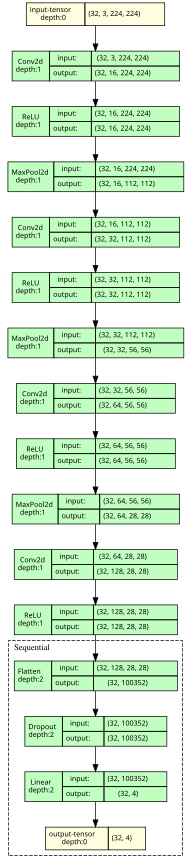

In [17]:
# Instantiate CNN model and move to computing device (CPU/GPU)
vanilla_model = SimpleCNN(
    input_shape,
    num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Display model architecture summary
summary(vanilla_model, input_size=input_shape)
model_graph = draw_graph(vanilla_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
model_graph.visual_graph

In [18]:
# Set up TensorBoard logging and save model architecture
experiment_name = "vanilla_cnn"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(vanilla_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

## **Training Functions**

In [19]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [20]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [21]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [22]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [23]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## **Model Training**

In [ ]:
%%time
# Train model and track training history
vanilla_model, vanilla_history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="vanilla_cnn",
    patience=PATIENCE
)

# Update best model if current performance is superior
if vanilla_history['val_f1'][-1] > best_performance:
    best_model = vanilla_model
    best_performance = vanilla_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(vanilla_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.2958, F1 Score=0.2746 | Val: Loss=1.4964, F1 Score=0.2384
Epoch   2/100 | Train: Loss=1.2308, F1 Score=0.3805 | Val: Loss=1.6572, F1 Score=0.2646
Epoch   3/100 | Train: Loss=1.2245, F1 Score=0.4059 | Val: Loss=1.7394, F1 Score=0.2516
Epoch   4/100 | Train: Loss=1.2482, F1 Score=0.3396 | Val: Loss=1.3835, F1 Score=0.1913
Epoch   5/100 | Train: Loss=1.2005, F1 Score=0.4391 | Val: Loss=1.4415, F1 Score=0.1921
Epoch   6/100 | Train: Loss=1.1421, F1 Score=0.4615 | Val: Loss=1.5959, F1 Score=0.2236
Epoch   7/100 | Train: Loss=1.1204, F1 Score=0.4649 | Val: Loss=1.8124, F1 Score=0.2460
Epoch   8/100 | Train: Loss=1.1064, F1 Score=0.4580 | Val: Loss=1.7005, F1 Score=0.2287
Epoch   9/100 | Train: Loss=1.0718, F1 Score=0.5118 | Val: Loss=1.7619, F1 Score=0.2573
Epoch  10/100 | Train: Loss=1.0200, F1 Score=0.5250 | Val: Loss=1.9376, F1 Score=0.2559
Epoch  11/100 | Train: Loss=0.9404, F1 Score=0.5805 | Val: Loss=2.1994, F1 Score=0.2901
Epoch  12

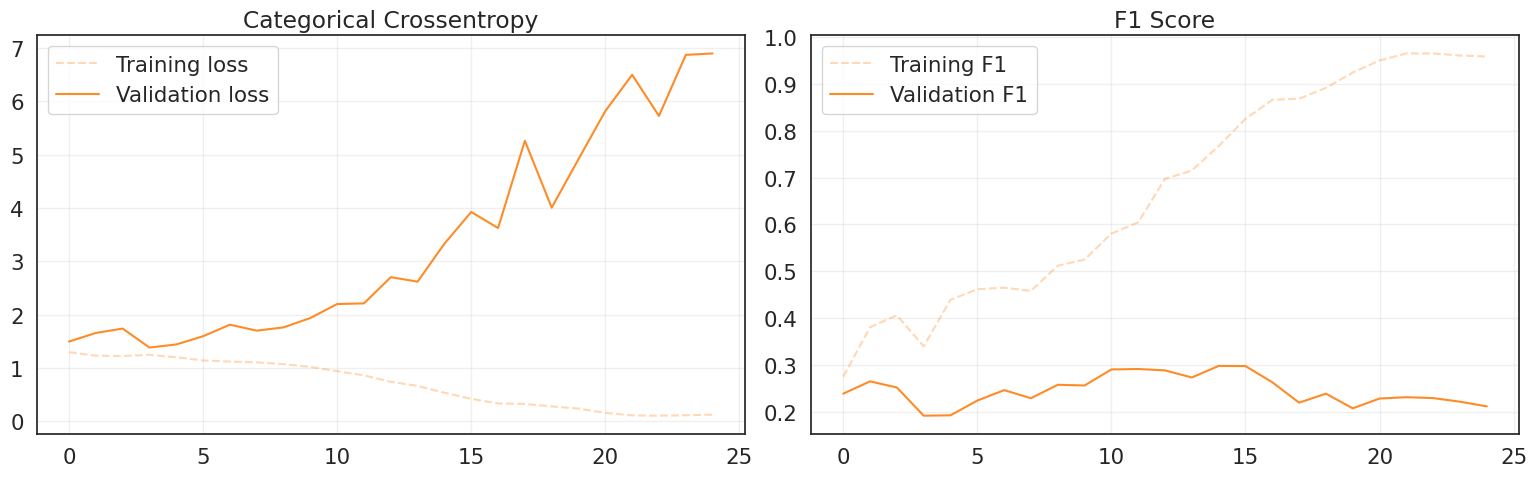

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(vanilla_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(vanilla_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation F1 score on the second axis
ax2.plot(vanilla_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(vanilla_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## **Image Augmentation**

In [ ]:
# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    # transforms.RandomRotation(30),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    # transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Split data into train and validation sets
train_df, val_df = train_test_split(
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels['label']
)

print(f"\nTrain size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")

print("\nTrain class distribution:")
print(train_df['label'].value_counts())
print("\nValidation class distribution:")
print(val_df['label'].value_counts())

# Create datasets
USE_MASK = False

train_dataset = TissueDataset(
    train_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=train_transform, use_mask=USE_MASK
)

val_dataset = TissueDataset(
    val_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=val_transform, use_mask=USE_MASK
)


Train size: 464
Validation size: 116

Train class distribution:
label
Luminal B          163
Luminal A          126
HER2(+)            120
Triple negative     55
Name: count, dtype: int64

Validation class distribution:
label
Luminal B          41
Luminal A          31
HER2(+)            30
Triple negative    14
Name: count, dtype: int64


In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
              ReLU-2         [-1, 16, 224, 224]               0
         MaxPool2d-3         [-1, 16, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]           4,640
              ReLU-5         [-1, 32, 112, 112]               0
         MaxPool2d-6           [-1, 32, 56, 56]               0
            Conv2d-7           [-1, 64, 56, 56]          18,496
              ReLU-8           [-1, 64, 56, 56]               0
         MaxPool2d-9           [-1, 64, 28, 28]               0
           Conv2d-10          [-1, 128, 28, 28]          73,856
             ReLU-11          [-1, 128, 28, 28]               0
          Flatten-12               [-1, 100352]               0
          Dropout-13               [-1, 100352]               0
           Linear-14                   

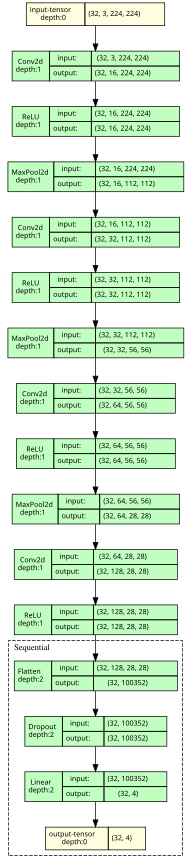

In [ ]:
# Instantiate CNN model with augmentation and move to computing device (CPU/GPU)
aug_model = SimpleCNN(
    input_shape,
    num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Display model architecture summary
summary(aug_model, input_size=input_shape)
model_graph = draw_graph(aug_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
model_graph.visual_graph

In [ ]:
# Set up TensorBoard logging and save model architecture
experiment_name = "augmented_cnn"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(aug_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(aug_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Train model with augmentation and track training history
aug_model, aug_history = fit(
    model=aug_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="augmented_cnn",
    patience=PATIENCE
)

# Update best model if current performance is superior
if aug_history['val_f1'][-1] > best_performance:
    best_model = aug_model
    best_performance = aug_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(aug_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.3880, F1 Score=0.2177 | Val: Loss=1.3327, F1 Score=0.1846
Epoch   2/100 | Train: Loss=1.3432, F1 Score=0.1954 | Val: Loss=1.3299, F1 Score=0.1846
Epoch   3/100 | Train: Loss=1.3315, F1 Score=0.1827 | Val: Loss=1.3343, F1 Score=0.1846
Epoch   4/100 | Train: Loss=1.3287, F1 Score=0.1827 | Val: Loss=1.3325, F1 Score=0.1846
Epoch   5/100 | Train: Loss=1.3344, F1 Score=0.1827 | Val: Loss=1.3252, F1 Score=0.1846
Epoch   6/100 | Train: Loss=1.3302, F1 Score=0.1827 | Val: Loss=1.3254, F1 Score=0.1846
Epoch   7/100 | Train: Loss=1.3259, F1 Score=0.1827 | Val: Loss=1.3255, F1 Score=0.1846
Epoch   8/100 | Train: Loss=1.3278, F1 Score=0.1827 | Val: Loss=1.3331, F1 Score=0.1846
Epoch   9/100 | Train: Loss=1.3320, F1 Score=0.1827 | Val: Loss=1.3263, F1 Score=0.1846
Epoch  10/100 | Train: Loss=1.3299, F1 Score=0.1827 | Val: Loss=1.3256, F1 Score=0.1846
Epoch  11/100 | Train: Loss=1.3281, F1 Score=0.1827 | Val: Loss=1.3255, F1 Score=0.1846
Early sto

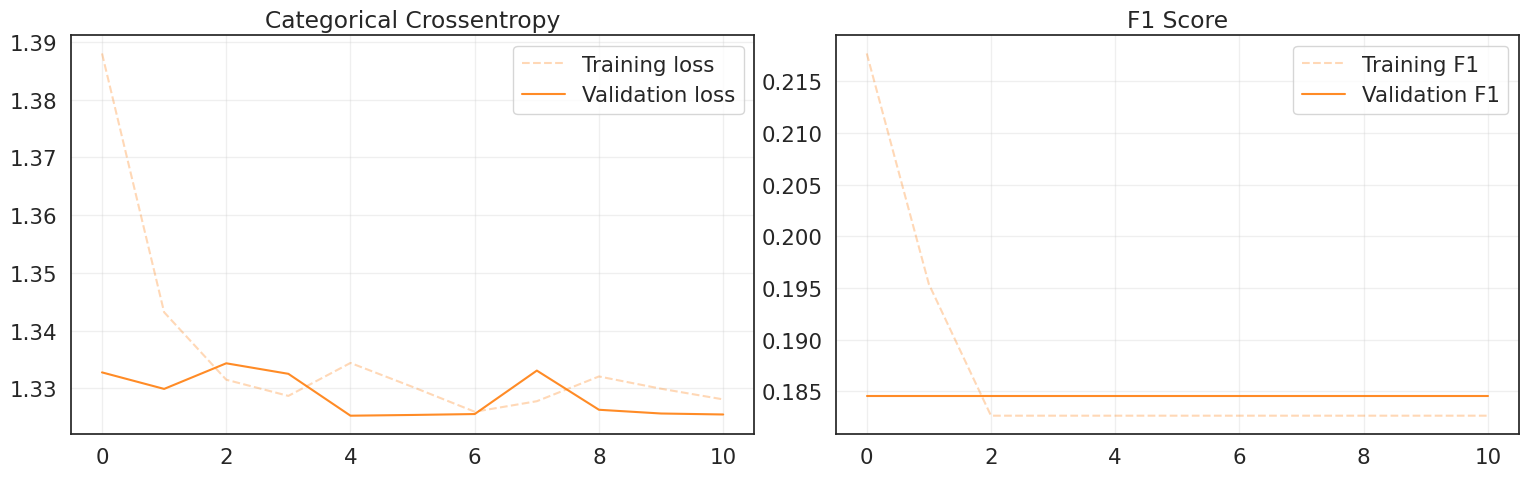

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(aug_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(aug_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation F1 score on the second axis
ax2.plot(aug_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(aug_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [ ]:
# Copy TensorBoard logs to accessible location for Colab
!rsync -a $current_dir"/"$logs_dir/ "/content/"$logs_dir/

# Launch TensorBoard interface
%tensorboard --logdir "/content/"$logs_dir

## **Transfer Learning**

In [ ]:
class EfficientNetB0TransferLearning(nn.Module):
    """EfficientNet-B0 with ImageNet pretrained weights."""

    def __init__(self, num_classes, dropout_rate=0.3, freeze_backbone=True):
        super().__init__()

        # Load weights pretrained on ImageNet
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
        )

        # Freeze the backbone layers (features)
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        # Replace classifier (Always trainable)
        in_features = self.backbone.classifier[-1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 225MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

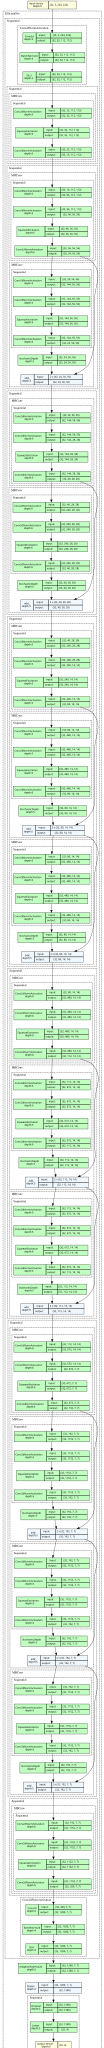

In [ ]:
# Create transfer learning model
tl_model = EfficientNetB0TransferLearning(num_classes, DROPOUT_RATE, freeze_backbone=True).to(device)

# Display model summary
summary(tl_model, input_size=input_shape)
model_graph = draw_graph(tl_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True, depth=6)
model_graph.visual_graph

In [ ]:
# Create data loaders with different settings for each phase
train_tl_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_tl_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Setup training
experiment_name = "transfer_learning_54"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
optimizer = torch.optim.Adam(tl_model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Train with transfer learning
tl_model, tl_history = fit(
    model=tl_model,
    train_loader=train_tl_loader,
    val_loader=val_tl_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=5,
    experiment_name=experiment_name,
    patience=PATIENCE
)

final_val_acc = round(max(tl_history['val_f1']) * 100, 2)
print(f'Final validation accuracy: {final_val_acc}%')

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.3529, F1 Score=0.3168 | Val: Loss=1.3386, F1 Score=0.2025
Epoch   5/100 | Train: Loss=1.1204, F1 Score=0.4978 | Val: Loss=1.3485, F1 Score=0.3128
Epoch  10/100 | Train: Loss=1.0134, F1 Score=0.5709 | Val: Loss=1.4029, F1 Score=0.3463
Epoch  15/100 | Train: Loss=0.9143, F1 Score=0.6772 | Val: Loss=1.4500, F1 Score=0.3191
Epoch  20/100 | Train: Loss=0.8403, F1 Score=0.7018 | Val: Loss=1.4931, F1 Score=0.3243
Early stopping triggered after 22 epochs.
Best model restored from epoch 12 with val_f1 0.3619
Final validation accuracy: 36.19%
CPU times: user 38.8 s, sys: 6.13 s, total: 44.9 s
Wall time: 21min 16s


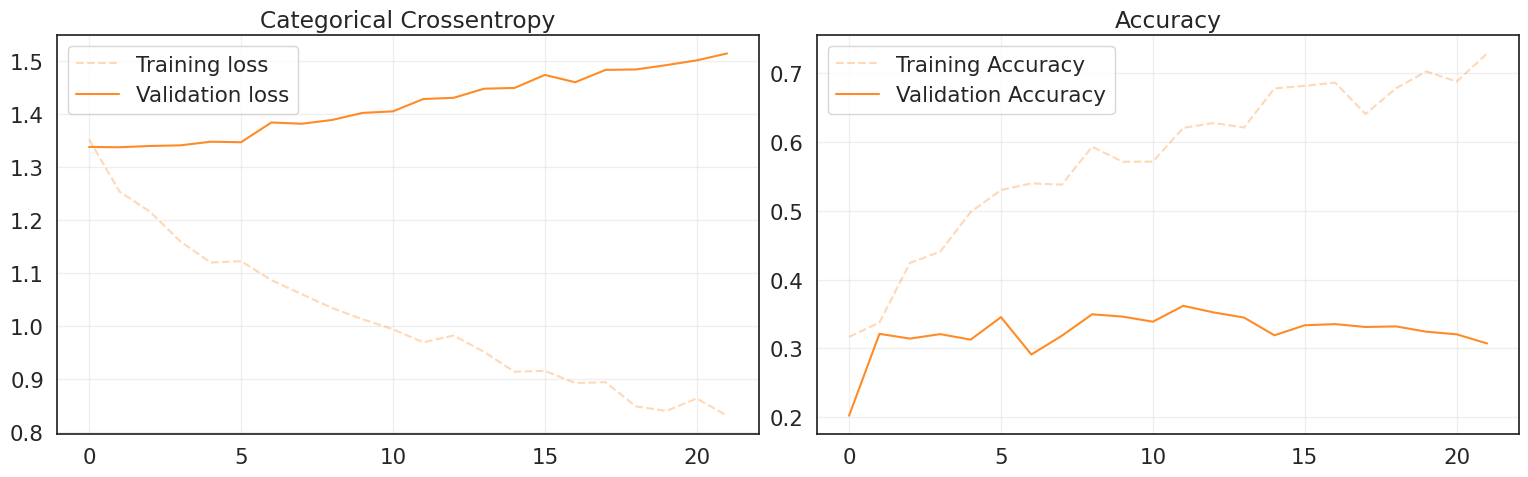

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(tl_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(tl_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(tl_history['train_f1'], label='Training Accuracy', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(tl_history['val_f1'], label='Validation Accuracy', alpha=0.9, color='#ff7f0e')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## **Fine-Tuning**

In [24]:
class EfficientNetB0FT(nn.Module):
    """EfficientNet-B0 with ImageNet pretrained weights."""

    def __init__(self, num_classes, dropout_rate=0.3, freeze_backbone=True):
        super().__init__()

        # Load weights pretrained on ImageNet
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
        )

        # Freeze the backbone layers (features)
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        # Replace classifier (Always trainable)
        in_features = self.backbone.classifier[-1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

In [25]:
# Load the transfer learning model
ft_model = EfficientNetB0FT(num_classes, DROPOUT_RATE, freeze_backbone=False).to(device)
ft_model.load_state_dict(torch.load("models/transfer_learning_54_model.pt"))

# Unfreeze the last N layers of the backbone
N_LAYERS_TO_UNFREEZE = 2

# Strategy: Freeze everything first, then unfreeze the last few blocks
for param in ft_model.parameters():
    param.requires_grad = False

# The classifier is always trainable
for param in ft_model.backbone.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 2 blocks of the feature extractor (EfficientNet-B0 has 9 blocks usually)
# Adjust slice index [-2:] to unfreeze more or fewer layers
for block in ft_model.backbone.features[-N_LAYERS_TO_UNFREEZE:]:
    for param in block.parameters():
        param.requires_grad = True

# Check trainable parameters
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 89.2MB/s]


Trainable parameters: 1,134,516 / 4,012,672


In [26]:
# Create data loaders with different settings for each phase
train_ft_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_ft_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [27]:
# Setup Training (Lower learning rate for Fine-Tuning)
experiment_name = "fine_tuning_54"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4) # 10x smaller LR
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [28]:
%%time
# Fine-tune the model
ft_model, ft_history = fit(
    model=ft_model,
    train_loader=train_ft_loader,
    val_loader=val_ft_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=5,
    experiment_name=experiment_name,
    patience=PATIENCE
)

final_val_acc = round(max(ft_history['val_f1']) * 100, 2)
print(f'Final validation accuracy: {final_val_acc}%')

Training 100 epochs...
Epoch   1/100 | Train: Loss=0.9562, F1 Score=0.6125 | Val: Loss=1.4393, F1 Score=0.3373
Epoch   5/100 | Train: Loss=0.7786, F1 Score=0.7581 | Val: Loss=1.4622, F1 Score=0.3216
Epoch  10/100 | Train: Loss=0.5926, F1 Score=0.8526 | Val: Loss=1.5167, F1 Score=0.3670
Epoch  15/100 | Train: Loss=0.4352, F1 Score=0.9391 | Val: Loss=1.5759, F1 Score=0.3396
Epoch  20/100 | Train: Loss=0.3290, F1 Score=0.9506 | Val: Loss=1.6517, F1 Score=0.2980
Early stopping triggered after 20 epochs.
Best model restored from epoch 10 with val_f1 0.3670
Final validation accuracy: 36.7%
CPU times: user 56.6 s, sys: 5.68 s, total: 1min 2s
Wall time: 14min 28s


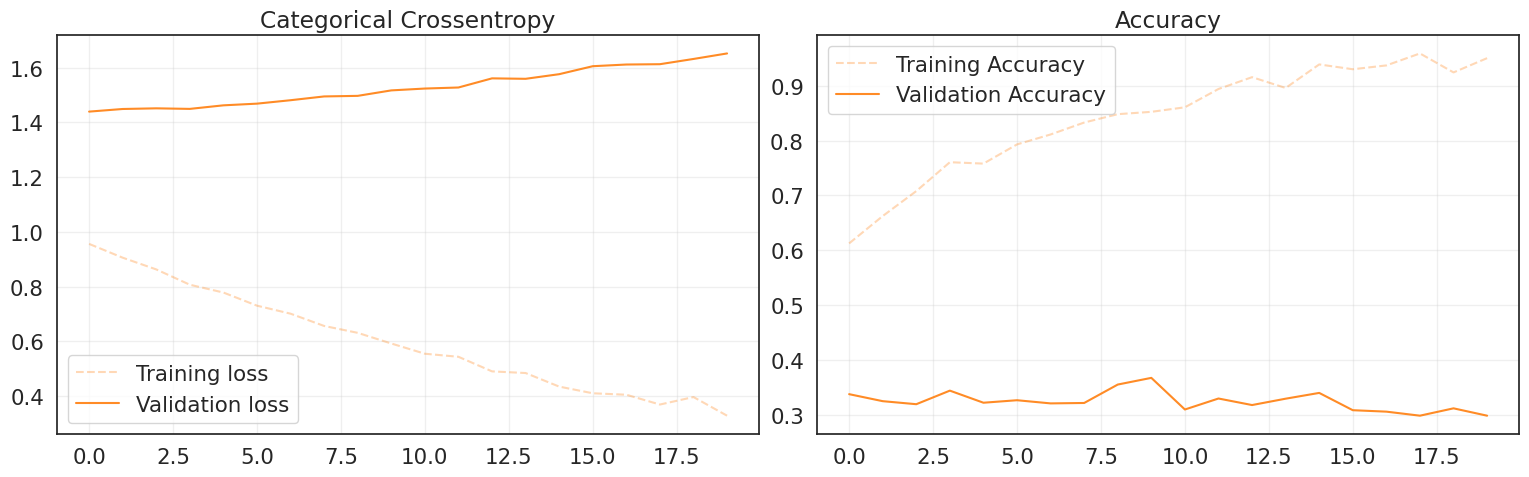

In [29]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(ft_history['train_f1'], label='Training Accuracy', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_f1'], label='Validation Accuracy', alpha=0.9, color='#ff7f0e')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [30]:
# Copy TensorBoard logs to accessible location for Colab
!rsync -a $current_dir"/"$logs_dir/ "/content/"$logs_dir/

# Launch TensorBoard interface
%tensorboard --logdir "/content/"$logs_dir

Output hidden; open in https://colab.research.google.com to view.

## **Inference**

In [31]:
# Get list of test images
test_files = sorted([f for f in os.listdir(TEST_DATA_DIR) if f.endswith('.png') and 'img_' in f])
print(f"Found {len(test_files)} test images")

# Display a few test file names
print("\nFirst 5 test files:")
for i in range(min(5, len(test_files))):
    print(f"  {test_files[i]}")

# Create test dataset
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = TestTissueDataset(
    test_files,
    TEST_DATA_DIR,
    transform=test_transform,
    use_mask=USE_MASK
)

# Create test data loader
test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"\nTest loader created with {len(test_loader)} batches")

Found 477 test images

First 5 test files:
  img_0000.png
  img_0001.png
  img_0002.png
  img_0003.png
  img_0004.png

Test loader created with 15 batches


In [32]:
def predict_test_set(model, test_loader, device, idx_to_label):
    """
    Generate predictions for the entire test set.

    Args:
        model (nn.Module): Trained neural network model
        test_loader (DataLoader): DataLoader containing test images
        device (torch.device): Computing device (CPU/GPU)
        idx_to_label (dict): Mapping from class indices to label names

    Returns:
        tuple: (image_filenames, predicted_labels)
    """
    model.eval()

    all_predictions = []
    all_filenames = []

    print("Generating predictions...")

    with torch.no_grad():
        for batch_idx, (images, filenames) in enumerate(test_loader):
            # Move images to device
            images = images.to(device)

            # Forward pass with mixed precision
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(images)

            # Get predicted class indices
            predictions = logits.argmax(dim=1).cpu().numpy()

            # Store results
            all_predictions.extend(predictions)
            all_filenames.extend(filenames)

            # Progress update
            if (batch_idx + 1) % 10 == 0:
                print(f"Processed {(batch_idx + 1) * len(images)}/{len(test_dataset)} images")

    # Convert class indices to label names
    predicted_labels = [idx_to_label[idx] for idx in all_predictions]

    print(f"\nPrediction complete! Generated {len(predicted_labels)} predictions")

    return all_filenames, predicted_labels

def create_submission_file(filenames, labels, model_name='model'):
    """
    Create a submission CSV file in the required format with unique timestamp.

    Args:
        filenames (list): List of image filenames
        labels (list): List of predicted labels
        model_name (str): Name of the model used for predictions

    Returns:
        tuple: (submission_df, output_path)
    """
    from datetime import datetime

    # Generate unique filename with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_path = f'submission_{model_name}_{timestamp}.csv'

    # Create dataframe
    submission_df = pd.DataFrame({
        'sample_index': filenames,
        'label': labels
    })

    # Save to CSV
    submission_df.to_csv(output_path, index=False)

    print(f"\n{'='*70}")
    print(f"SUBMISSION FILE CREATED")
    print(f"{'='*70}")
    print(f"File saved to: {output_path}")
    print(f"Model: {model_name}")
    print(f"Timestamp: {timestamp}")
    print(f"Total predictions: {len(submission_df)}")

    # Display class distribution in predictions
    print(f"\nPredicted class distribution:")
    print(submission_df['label'].value_counts().sort_index())

    # Display first few rows
    print(f"\nFirst 10 rows of submission file:")
    print(submission_df.head(10))

    return submission_df, output_path

In [33]:
# Load the best model (fine-tuned model in this case)
print("\n" + "="*70)
print("LOADING BEST MODEL FOR INFERENCE")
print("="*70)

# Choose which model to use for final predictions
inference_model = EfficientNetB0FT(num_classes, DROPOUT_RATE, freeze_backbone=False).to(device)
inference_model.load_state_dict(torch.load("models/fine_tuning_54_model.pt"))

# Generate predictions on test set
test_filenames, test_predictions = predict_test_set(
    model=inference_model,
    test_loader=test_loader,
    device=device,
    idx_to_label=idx_to_label
)

# Create submission CSV file
submission_df, submission_path = create_submission_file(
    filenames=test_filenames,
    labels=test_predictions,
    model_name='model_ft_54'
)

# Verify the submission file format
print("\n" + "="*70)
print("SUBMISSION FILE VERIFICATION")
print("="*70)

# Check if file exists
if os.path.exists(submission_path):
    print("Submission file exists")

    # Verify file format
    verify_df = pd.read_csv(submission_path)

    # Check column names
    if list(verify_df.columns) == ['sample_index', 'label']:
        print("Column names are correct")
    else:
        print("WARNING: Column names are incorrect!")
        print(f"Expected: ['sample_index', 'label']")
        print(f"Found: {list(verify_df.columns)}")

    # Check number of predictions
    expected_count = len(test_files)
    actual_count = len(verify_df)
    if actual_count == expected_count:
        print(f"Number of predictions is correct ({actual_count})")
    else:
        print(f"WARNING: Number of predictions mismatch!")
        print(f"Expected: {expected_count}")
        print(f"Found: {actual_count}")

    # Check for valid labels
    valid_labels = set(label_to_idx.keys())
    predicted_labels_set = set(verify_df['label'].unique())
    if predicted_labels_set.issubset(valid_labels):
        print("All predicted labels are valid")
    else:
        invalid_labels = predicted_labels_set - valid_labels
        print(f"WARNING: Found invalid labels: {invalid_labels}")

    # Check for missing values
    if verify_df.isnull().sum().sum() == 0:
        print("No missing values")
    else:
        print("WARNING: Found missing values!")
        print(verify_df.isnull().sum())

    print("\n" + "="*70)
    print("READY FOR SUBMISSION!")
    print("="*70)

else:
    print("ERROR: Submission file was not created!")


LOADING BEST MODEL FOR INFERENCE
Generating predictions...
  Processed 320/477 images

Prediction complete! Generated 477 predictions

SUBMISSION FILE CREATED
File saved to: submission_model_ft_54_20251215_142507.csv
Model: model_ft_54
Timestamp: 20251215_142507
Total predictions: 477

Predicted class distribution:
label
HER2(+)            121
Luminal A           79
Luminal B          258
Triple negative     19
Name: count, dtype: int64

First 10 rows of submission file:
   sample_index            label
0  img_0000.png        Luminal B
1  img_0001.png        Luminal A
2  img_0002.png        Luminal B
3  img_0003.png          HER2(+)
4  img_0004.png        Luminal B
5  img_0005.png        Luminal B
6  img_0006.png  Triple negative
7  img_0007.png        Luminal B
8  img_0008.png        Luminal B
9  img_0009.png          HER2(+)

SUBMISSION FILE VERIFICATION
Submission file exists
Column names are correct
Number of predictions is correct (477)
All predicted labels are valid
No missing v


Visualizing random test predictions...


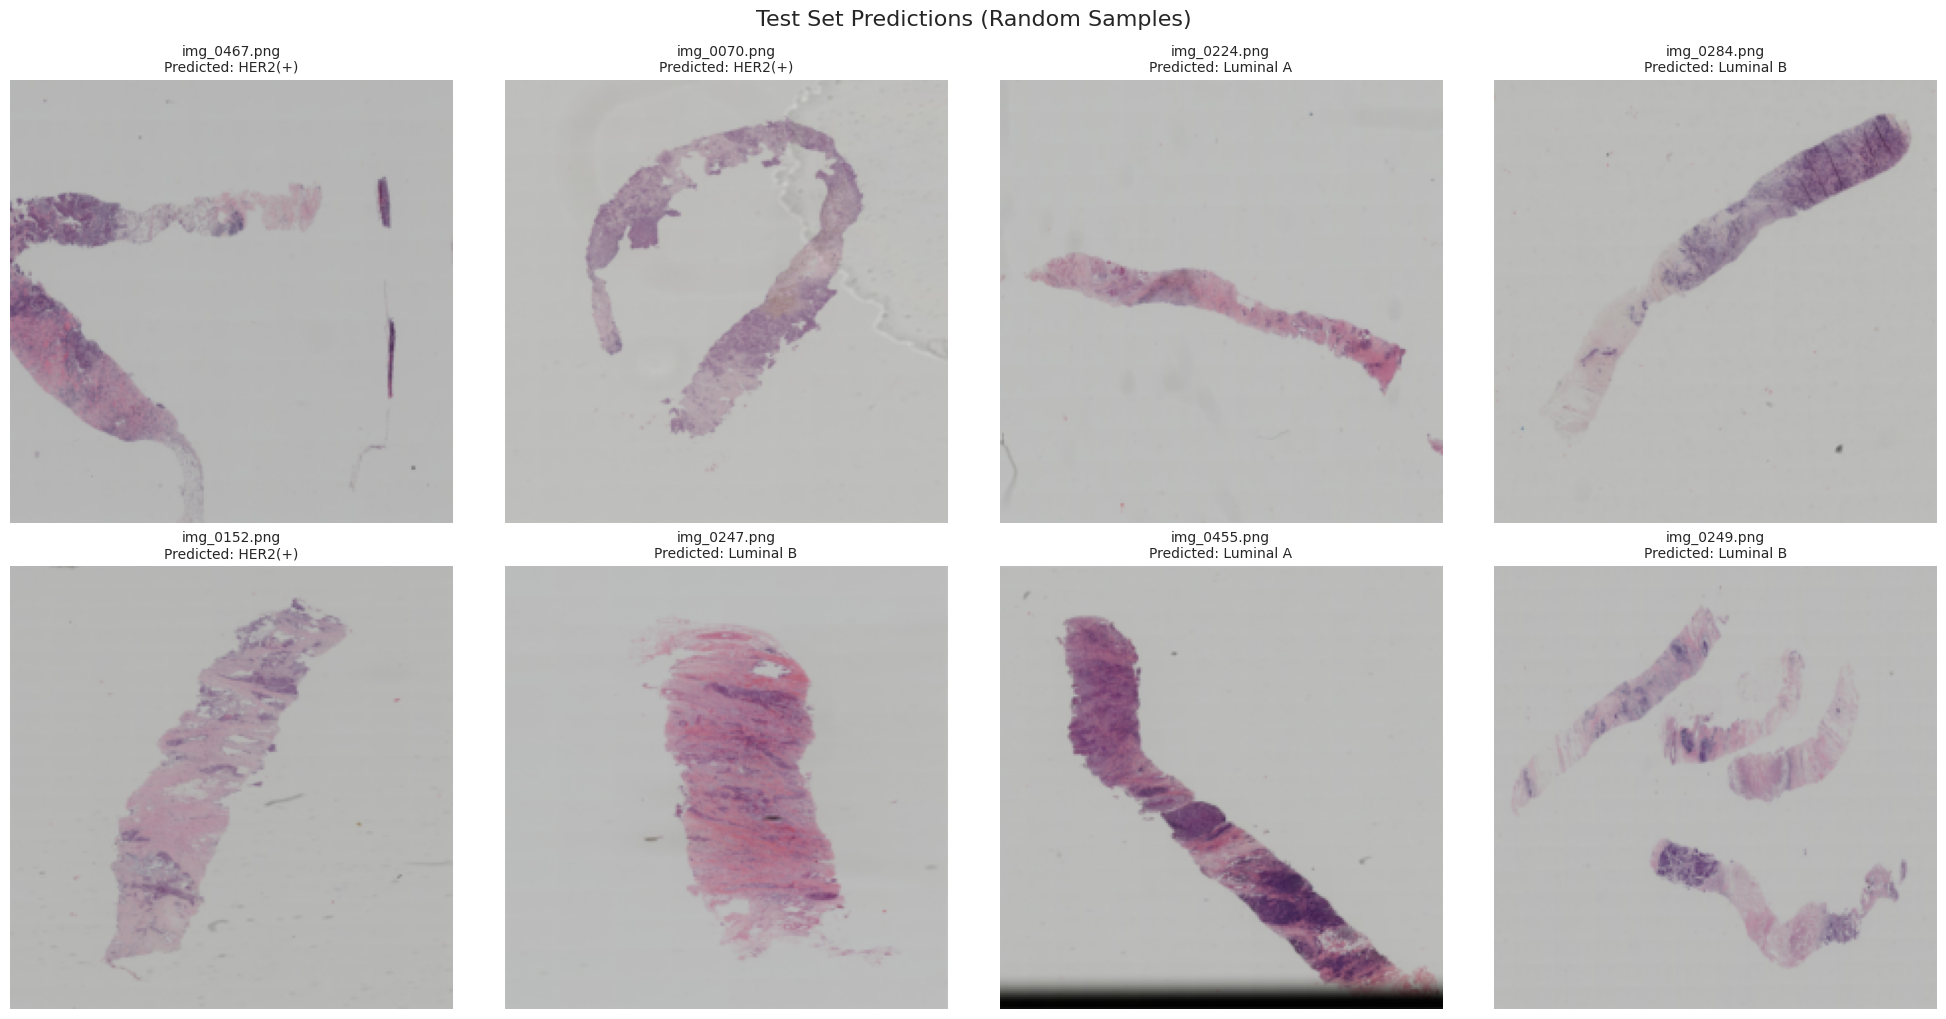

In [34]:
# Optional: Visualize some test predictions
def visualize_test_predictions(test_dataset, predictions, idx_to_label, n_samples=8):
    """
    Visualize random test images with their predicted labels.

    Args:
        test_dataset (Dataset): Test dataset containing images
        predictions (list): List of predicted class indices
        idx_to_label (dict): Mapping from indices to label names
        n_samples (int): Number of samples to display
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    # Select random samples
    sample_indices = random.sample(range(len(test_dataset)), min(n_samples, len(test_dataset)))

    for i, idx in enumerate(sample_indices):
        # Get image and filename
        img_tensor, filename = test_dataset[idx]

        # Denormalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = img_tensor * std + mean
        img_display = torch.clamp(img_display, 0, 1)
        img_display = img_display.permute(1, 2, 0).numpy()

        # Get prediction
        pred_label = test_predictions[test_filenames.index(filename)]

        # Display
        axes[i].imshow(img_display)
        axes[i].set_title(f"{filename}\nPredicted: {pred_label}", fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.suptitle('Test Set Predictions (Random Samples)', fontsize=16, y=1.02)
    plt.show()

# Visualize some predictions
print("\nVisualizing random test predictions...")
visualize_test_predictions(test_dataset, test_filenames, idx_to_label, n_samples=8)